In [1]:
import pandas as pd

In [3]:
train = pd.read_csv("../Data/train_1k.csv", header=None)
train.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
import numpy as np

In [5]:
# 이미지의 크기
np.sqrt(784)

28.0

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 6.0 MB


### Target으로 합당한지

In [7]:
train[0].value_counts()

0
7    117
1    116
4    105
9    100
2     99
0     98
6     94
3     93
5     92
8     87
Name: count, dtype: int64

In [8]:
87/117

0.7435897435897436

### Feature와 Target 분류

In [10]:
train.columns

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       775, 776, 777, 778, 779, 780, 781, 782, 783, 784],
      dtype='int64', length=785)

In [9]:
train_target = train.loc[:,0]
train_data = train.loc[:,1:]

In [11]:
train_target = train.loc[:,train.columns == 0]
train_data = train.loc[:,train.columns != 0]

### Train의 내용 보기

In [27]:
temp = np.array(train.loc[2, train.columns !=0])
print(temp.reshape(28, 28))

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0  67 232  39   0   0   0   0   0]
 [  0   0   0   0  62  81   0   0   0   0   0   0   0   0   0   0   0   0
    0   0 120 180  39   0   0   0   0   0]
 [  0   0   0   0 126 163   0   0   0   0   0   0   0   0   0   0   0   0
    0   2 153 210  40   0   0   0   0   0]
 [  0   0   0   0 220 163   0   0   0   0   0   0   0   0   0   

In [28]:
# train의 컬럼 줄이기
tempColumns = []
temp1 = temp.reshape(28, 28)
count = 0

for i in range(0, 28+1):
    if i % 2 == 1:
        for j in range(0, 28+1):
            if j % 2 == 1:
                tempColumns.append(temp1[i, j])
                count+=1

count

196

In [29]:
np.sqrt(196)

14.0

In [30]:
print(np.array(tempColumns).reshape(14,14))

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 232   0   0   0]
 [  0   0 163   0   0   0   0   0   0   2 210   0   0   0]
 [  0   0 163   0   0   0   0   0   0 183 125   0   0   0]
 [  0 120 163   0   0   0   0   0   0 231  29   0   0   0]
 [  0 159  67   0   0   0   0  14 178 254   0   0   0   0]
 [  0 150 237 207 253 250 198  91   5 250   0   0   0   0]
 [  0   0   0   0   0   0   0   0 169 137   0   0   0   0]
 [  0   0   0   0   0   0   0   0 169  57   0   0   0   0]
 [  0   0   0   0   0   0   0   0 169  96   0   0   0   0]
 [  0   0   0   0   0   0   0   0 169 153   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]]


In [32]:
test = pd.read_csv("../Data/test_1k.csv", header=None)
test.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
test_target = test.loc[:,0]
test_data = test.loc[:,1:]

### Machine Learning

In [34]:
# SVM
from sklearn.svm import SVC

In [35]:
clf = SVC()
clf.fit(train_data, train_target)

c:\Users\TJ\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC()

In [36]:
# 예측하기
pred = clf.predict(test_data)

In [37]:
pred

array([7, 2, 1, ..., 8, 4, 9], dtype=int64)

In [38]:
print(clf.score(train_data, train_target))
print(clf.score(test_data, test_target))

0.9820179820179821
0.8751248751248751


In [39]:
import matplotlib.pyplot as plt

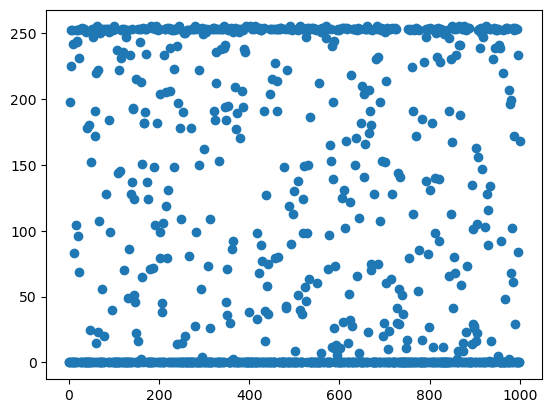

In [41]:
plt.scatter(
    train_data.index,
    train_data[300]
)

plt.show()

In [40]:
train_data[300]

0         0
1         0
2       198
3         0
4       225
       ... 
996       0
997      84
998       0
999       0
1000    168
Name: 300, Length: 1001, dtype: int64

### 로그변환
: 로그는 태생적으로 큰값을 작게 표기 하기 위해 고안된 방법이다.

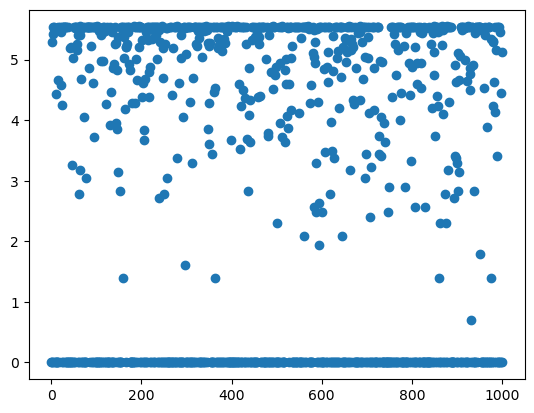

In [42]:
plt.scatter(
    train_data.index,
    np.log1p(train_data[300])
)

plt.show()

### data의 표준화

In [43]:
# train_data의 표준화
train_data = pd.DataFrame(np.log1p(train_data))
train_data.head()

,1,2,3,4,5,6,7,8,9,10,...,775,776,777,778,779,780,781,782,783,784
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [44]:
# test_data의 표준화
test_data = pd.DataFrame(np.log1p(test_data))
test_data.head()

,1,2,3,4,5,6,7,8,9,10,...,775,776,777,778,779,780,781,782,783,784
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### SVM으로 확인

In [45]:
clf = SVC()
clf.fit(train_data, train_target)

c:\Users\TJ\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC()

In [46]:
print(clf.score(train_data, train_target))
print(clf.score(test_data, test_target))

0.983016983016983
0.8901098901098901


> SVM    
- train : 0.983016983016983
- test  : 0.8901098901098901

### RandomForest로 확인

In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
rf = RandomForestClassifier()
rf.fit(train_data, train_target)

c:\Users\TJ\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier()

In [49]:
print(rf.score(train_data, train_target))
print(rf.score(test_data, test_target))

1.0
0.8551448551448552


### kNN으로 확인

In [50]:
from sklearn.neighbors import KNeighborsClassifier

In [51]:
knn = KNeighborsClassifier()

In [52]:
knn.fit(train_data, train_target)
print(knn.score(train_data, train_target))
print(knn.score(test_data, test_target))

c:\Users\TJ\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


0.9240759240759241
0.8411588411588412
